# 03 — Peak detection and tentative isotope identification

This notebook demonstrates peak detection and first-pass isotope matching.

Important scientific note:

SIMS peak assignment is not unique. Atomic ions, molecular ions, hydrides, oxides,
clusters, and matrix effects can all contribute. This notebook performs **candidate
matching**, not definitive chemical identification.

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum
from pymagsims.isotopes import load_builtin_isotopes

DATA = Path("../tests/data")
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")
isotopes = load_builtin_isotopes()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Detect peaks

In [4]:
peaks = spec.find_peaks(
    prominence=100,
    distance=5,
)

display(peaks.head(20))
print(f"Detected peaks: {len(peaks)}")

,Channel,measured_mass,intensity,peak_index,prominences,left_bases,right_bases
0,2070,12.142001,600.0,2069,600.0,2030,2177
1,2218,13.196964,254.0,2217,254.0,2177,2269
2,2362,14.262894,490.0,2361,489.0,2318,2402
3,2497,15.297566,871.0,2496,871.0,2318,2681
4,2624,16.302165,378.0,2623,376.0,2586,2681
5,2742,17.262715,119.0,2741,119.0,2691,2916
6,3440,23.479374,2033.0,3439,2033.0,3371,3530
7,3445,23.527206,1932.0,3444,217.0,3443,3530
8,3451,23.584666,1416.0,3450,163.0,3449,3530
9,3727,26.300927,1410.0,3726,132.0,3648,3728


Detected peaks: 108


## Assign isotope candidates

In [5]:
assignments = spec.assign_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
)

display(assignments.head(30))
print(f"Candidate assignments: {len(assignments)}")

,measured_mass,intensity,element,isotope,exact_mass,abundance,mass_error,abs_mass_error
0,12.142001,600.0,C,12C,12.000000,98.930,0.142001,0.142001
1,13.196964,254.0,C,13C,13.003355,1.070,0.193609,0.193609
2,56.742039,4005.0,Fe,57Fe,56.935393,2.119,-0.193354,0.193354
3,56.830325,2284.0,Fe,57Fe,56.935393,2.119,-0.105068,0.105068
4,56.918679,867.0,Fe,57Fe,56.935393,2.119,-0.016714,0.016714
5,62.744836,16600.0,Cu,63Cu,62.929598,69.150,-0.184762,0.184762
6,62.868545,8321.0,Cu,63Cu,62.929598,69.150,-0.061053,0.061053
7,62.992374,2749.0,Cu,63Cu,62.929598,69.150,0.062776,0.062776
8,63.737871,4989.0,Zn,64Zn,63.929142,49.170,-0.191271,0.191271
9,63.831363,4716.0,Zn,64Zn,63.929142,49.170,-0.097779,0.097779


Candidate assignments: 25


## Annotated spectrum

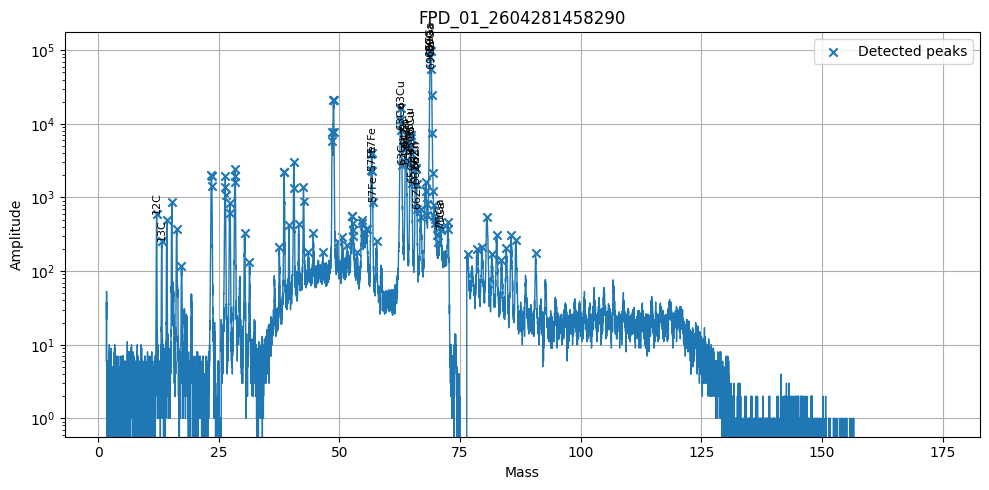

In [6]:
fig, ax, assignments = spec.plot_with_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
    log_y=True,
    annotate=True,
)

## Compare measured spectrum with isotope positions for selected elements

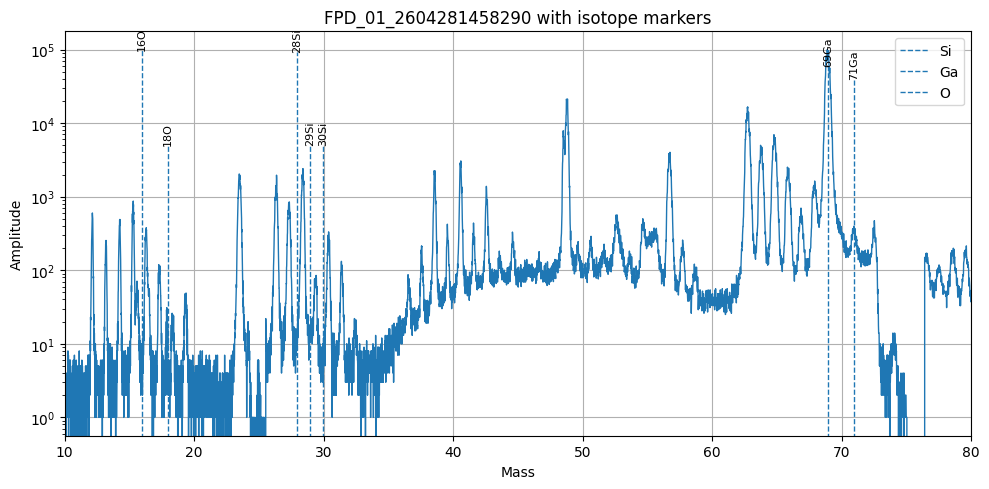

In [7]:
spec.plot_with_element_markers(
    isotope_table=isotopes,
    elements=["Si", "Ga", "O"],
    log_y=True,
    xlim=(10, 80),
    min_abundance=0.1,
);